# ch204 — Numerical Limits

**Part VII: Calculus**

---

## 1. Computing Limits Numerically

Instead of epsilon-delta proofs, a programmer's approach to limits is direct: evaluate the function at inputs that get progressively closer to the target point, and observe the pattern.

This is both practical and educational. It also reveals something important: numerical computation has limits of its own, due to floating-point precision *(introduced in ch038 — Precision and Floating Point Errors)*.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def numerical_limit(f, a, direction='both', steps=20, start_h=1.0):
    """
    Estimate lim_{x->a} f(x) by evaluating f at points approaching a.
    
    Returns: (h_values, f_values) for the approach.
    """
    h_values = start_h / (2.0 ** np.arange(steps))
    results = {}
    
    if direction in ('right', 'both'):
        results['right'] = [(h, f(a + h)) for h in h_values]
    if direction in ('left', 'both'):
        results['left']  = [(h, f(a - h)) for h in h_values]
    
    return results


# Example 1: lim_{x->0} sin(x)/x
f1 = lambda x: np.sin(x) / x
r1 = numerical_limit(f1, 0.0)

print('lim_{x->0} sin(x)/x')
print(f'{"h":>12}  {"from right":>15}  {"from left":>15}')
print('-' * 48)
for (h_r, v_r), (h_l, v_l) in zip(r1['right'], r1['left']):
    print(f'{h_r:>12.2e}  {v_r:>15.10f}  {v_l:>15.10f}')

lim_{x->0} sin(x)/x
           h       from right        from left
------------------------------------------------
    1.00e+00     0.8414709848     0.8414709848
    5.00e-01     0.9588510772     0.9588510772
    2.50e-01     0.9896158370     0.9896158370
    1.25e-01     0.9973978671     0.9973978671
    6.25e-02     0.9993490855     0.9993490855
    3.12e-02     0.9998372475     0.9998372475
    1.56e-02     0.9999593104     0.9999593104
    7.81e-03     0.9999898275     0.9999898275
    3.91e-03     0.9999974569     0.9999974569
    1.95e-03     0.9999993642     0.9999993642
    9.77e-04     0.9999998411     0.9999998411
    4.88e-04     0.9999999603     0.9999999603
    2.44e-04     0.9999999901     0.9999999901
    1.22e-04     0.9999999975     0.9999999975
    6.10e-05     0.9999999994     0.9999999994
    3.05e-05     0.9999999998     0.9999999998
    1.53e-05     1.0000000000     1.0000000000
    7.63e-06     1.0000000000     1.0000000000
    3.81e-06     1.0000000000     1.00

In [2]:
# Example 2: lim_{x->1} (x^2 - 1)/(x - 1)
# Algebraically this simplifies to x+1, so the limit should be 2
f2 = lambda x: (x**2 - 1) / (x - 1)
r2 = numerical_limit(f2, 1.0)

print('lim_{x->1} (x^2 - 1)/(x - 1)   [expect: 2.0]')
print(f'{"h":>12}  {"from right":>15}  {"from left":>15}')
print('-' * 48)
for (h_r, v_r), (h_l, v_l) in zip(r2['right'][:12], r2['left'][:12]):
    print(f'{h_r:>12.2e}  {v_r:>15.10f}  {v_l:>15.10f}')

lim_{x->1} (x^2 - 1)/(x - 1)   [expect: 2.0]
           h       from right        from left
------------------------------------------------
    1.00e+00     3.0000000000     1.0000000000
    5.00e-01     2.5000000000     1.5000000000
    2.50e-01     2.2500000000     1.7500000000
    1.25e-01     2.1250000000     1.8750000000
    6.25e-02     2.0625000000     1.9375000000
    3.12e-02     2.0312500000     1.9687500000
    1.56e-02     2.0156250000     1.9843750000
    7.81e-03     2.0078125000     1.9921875000
    3.91e-03     2.0039062500     1.9960937500
    1.95e-03     2.0019531250     1.9980468750
    9.77e-04     2.0009765625     1.9990234375
    4.88e-04     2.0004882812     1.9995117188


## 2. Floating-Point Breakdown

When h gets too small, subtraction of nearly-equal numbers causes **catastrophic cancellation** — a loss of significant digits. The numerical estimate degrades.

In [3]:
# Watch the breakdown: compute (x^2-1)/(x-1) as x -> 1
h_vals = np.array([10**(-k) for k in range(1, 17)])
a = 1.0
f3 = lambda x: (x**2 - 1) / (x - 1)

estimates = []
for h in h_vals:
    try:
        val = f3(a + h)
    except ZeroDivisionError:
        val = np.nan
    estimates.append(val)

errors = [abs(e - 2.0) if not np.isnan(e) else np.nan for e in estimates]

print(f'{"h":>12}  {"estimate":>16}  {"error":>14}')
print('-' * 48)
for h, est, err in zip(h_vals, estimates, errors):
    err_str = f'{err:.2e}' if err is not None and not np.isnan(err) else 'NaN'
    est_str = f'{est:.10f}' if not np.isnan(est) else 'NaN'
    print(f'{h:>12.2e}  {est_str:>16}  {err_str:>14}')

print()
print('For h < 1e-8, floating-point error dominates. The estimate degrades.')
print('This is the same issue seen in ch038 — Precision and Floating Point Errors.')

           h          estimate           error
------------------------------------------------
    1.00e-01      2.1000000000        1.00e-01
    1.00e-02      2.0100000000        1.00e-02
    1.00e-03      2.0010000000        1.00e-03
    1.00e-04      2.0001000000        1.00e-04
    1.00e-05      2.0000100000        1.00e-05
    1.00e-06      2.0000010001        1.00e-06
    1.00e-07      2.0000000999        9.99e-08
    1.00e-08      2.0000000000        0.00e+00
    1.00e-09      2.0000000000        0.00e+00
    1.00e-10      2.0000000000        0.00e+00
    1.00e-11      2.0000000000        0.00e+00
    1.00e-12      2.0000000000        0.00e+00
    1.00e-13      2.0000000000        0.00e+00
    1.00e-14      2.0000000000        0.00e+00
    1.00e-15      2.0000000000        0.00e+00
    1.00e-16               NaN             NaN

For h < 1e-8, floating-point error dominates. The estimate degrades.
This is the same issue seen in ch038 — Precision and Floating Point Errors.


C:\Users\user\AppData\Local\Temp\ipykernel_17792\579443449.py:4: RuntimeWarning: invalid value encountered in scalar divide
  f3 = lambda x: (x**2 - 1) / (x - 1)


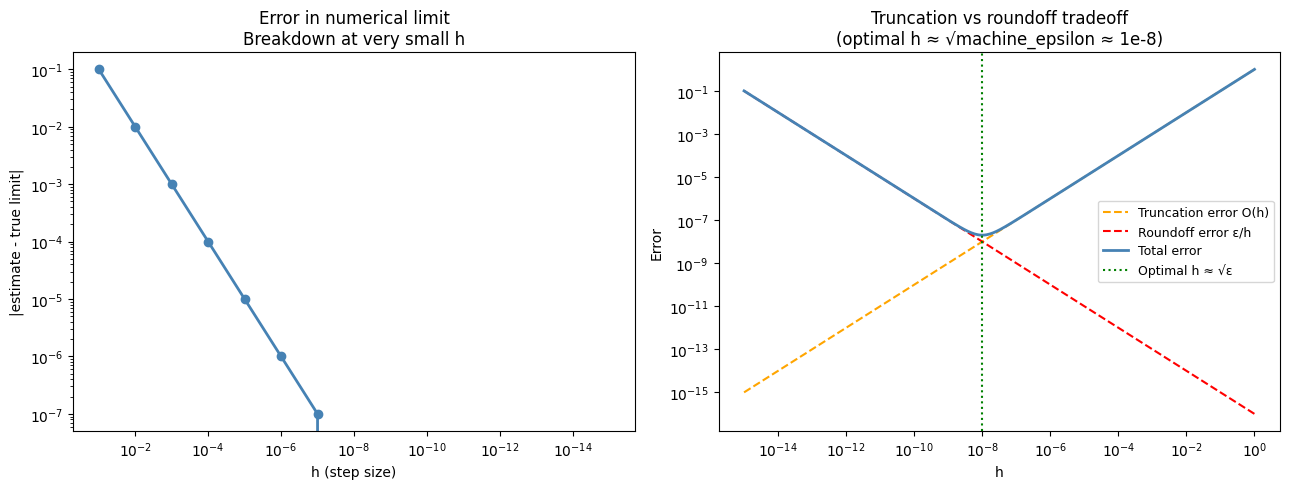

In [4]:
# Visualize the breakdown
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

valid_h    = [h for h, e in zip(h_vals, errors) if e is not None and not np.isnan(e)]
valid_errs = [e for e in errors if e is not None and not np.isnan(e)]

axes[0].loglog(valid_h, valid_errs, 'o-', color='steelblue', linewidth=2)
axes[0].set_xlabel('h (step size)')
axes[0].set_ylabel('|estimate - true limit|')
axes[0].set_title('Error in numerical limit\nBreakdown at very small h')
axes[0].invert_xaxis()

# Optimal h zone illustration
h_range = np.logspace(-15, 0, 300)
# truncation error decreases as h->0, roundoff error increases
truncation = h_range          # O(h) for first-order approx
roundoff   = 1e-16 / h_range  # machine epsilon / h
total = truncation + roundoff

axes[1].loglog(h_range, truncation, '--', color='orange', label='Truncation error O(h)')
axes[1].loglog(h_range, roundoff,   '--', color='red',    label='Roundoff error ε/h')
axes[1].loglog(h_range, total,      '-',  color='steelblue', linewidth=2, label='Total error')
axes[1].axvline(1e-8, color='green', linestyle=':', label='Optimal h ≈ √ε')
axes[1].set_xlabel('h')
axes[1].set_ylabel('Error')
axes[1].set_title('Truncation vs roundoff tradeoff\n(optimal h ≈ √machine_epsilon ≈ 1e-8)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## 3. One-Sided Limits

Some functions have different left and right limits. Checking both sides tells you whether the limit exists.

In [5]:
def check_limit(f, a, steps=15, tol=1e-6):
    """Check whether lim_{x->a} f(x) exists by comparing left and right limits."""
    h_vals = 1.0 / (2.0 ** np.arange(steps))
    
    right_vals = np.array([f(a + h) for h in h_vals])
    left_vals  = np.array([f(a - h) for h in h_vals])
    
    # Use median of last 5 values to reduce noise
    right_limit = np.median(right_vals[-5:])
    left_limit  = np.median(left_vals[-5:])
    
    exists = abs(right_limit - left_limit) < tol
    return {
        'right_limit': right_limit,
        'left_limit':  left_limit,
        'limit_exists': exists,
        'limit_value':  (right_limit + left_limit) / 2 if exists else None
    }


cases = [
    ('sin(x)/x at x=0',       lambda x: np.sin(x)/x, 0.0),
    ('|x|/x at x=0 (sign)',   lambda x: np.abs(x)/x, 0.0),
    ('x^2 at x=2',            lambda x: x**2,         2.0),
    ('1/x at x=0',            lambda x: 1/x,           0.0),
]

for name, f, a in cases:
    try:
        result = check_limit(f, a)
        print(f"{name}")
        print(f"  Right limit: {result['right_limit']:.6f}")
        print(f"  Left limit:  {result['left_limit']:.6f}")
        print(f"  Limit exists: {result['limit_exists']}" +
              (f", value: {result['limit_value']:.6f}" if result['limit_exists'] else ''))
        print()
    except Exception as e:
        print(f"{name}: Error — {e}\n")

sin(x)/x at x=0
  Right limit: 1.000000
  Left limit:  1.000000
  Limit exists: True, value: 1.000000

|x|/x at x=0 (sign)
  Right limit: 1.000000
  Left limit:  -1.000000
  Limit exists: False

x^2 at x=2
  Right limit: 4.000977
  Left limit:  3.999023
  Limit exists: False

1/x at x=0
  Right limit: 4096.000000
  Left limit:  -4096.000000
  Limit exists: False



## 4. Limits in Machine Learning Contexts

The derivative formula is a limit, but it's not the only place limits matter in ML:

- **Learning rate → 0**: gradient descent with decaying lr converges *in the limit* to a stationary point
- **Batch size → ∞**: gradient estimated from a full batch approaches the true gradient in the limit
- **Softmax temperature → 0**: the softmax output approaches a one-hot distribution *(see ch065 — Sigmoid Functions)*
- **Log-sum-exp trick**: a numerically stable way to compute log(Σ exp(xᵢ)), which involves limits of floating-point arithmetic

In [6]:
# Softmax temperature limiting behavior
def softmax(x, temperature=1.0):
    z = x / temperature
    z = z - np.max(z)  # numerical stability
    e = np.exp(z)
    return e / e.sum()

logits = np.array([2.0, 1.0, 0.5, -0.5])
temps  = [10.0, 1.0, 0.5, 0.1, 0.01]

print('Softmax output as temperature T → 0')
print(f'Logits: {logits}')
print()
print(f'{"T":>8}  {"p[0]":>8}  {"p[1]":>8}  {"p[2]":>8}  {"p[3]":>8}')
print('-' * 50)
for T in temps:
    p = softmax(logits, T)
    print(f'{T:>8.2f}  {p[0]:>8.4f}  {p[1]:>8.4f}  {p[2]:>8.4f}  {p[3]:>8.4f}')

print()
print('As T→0, the distribution concentrates on the maximum logit (index 0).')
print('In the limit T→0: softmax → one-hot at argmax.')
print('As T→∞: softmax → uniform distribution.')

Softmax output as temperature T → 0
Logits: [ 2.   1.   0.5 -0.5]

       T      p[0]      p[1]      p[2]      p[3]
--------------------------------------------------
   10.00    0.2821    0.2553    0.2428    0.2197
    1.00    0.5977    0.2199    0.1334    0.0491
    0.50    0.8390    0.1135    0.0418    0.0057
    0.10    1.0000    0.0000    0.0000    0.0000
    0.01    1.0000    0.0000    0.0000    0.0000

As T→0, the distribution concentrates on the maximum logit (index 0).
In the limit T→0: softmax → one-hot at argmax.
As T→∞: softmax → uniform distribution.


## 5. Summary

- Numerical limits: evaluate f at points approaching a, observe convergence
- Optimal step size for numerical differentiation: h ≈ √(machine epsilon) ≈ 1e-8
- Very small h causes floating-point cancellation, degrading the estimate
- One-sided limits can disagree — test both left and right
- Limits appear throughout ML: optimizer convergence, temperature scaling, numerical stability

---

## 6. Forward References

The numerical differentiation technique introduced here is the forward finite difference method — ch207 — Numerical Derivatives extends this to centered differences and higher-order approximations with better accuracy. The floating-point instability observed here motivates the log-sum-exp trick, which reappears in ch261 — probability experiments.